In [ ]:
import numpy as np
import cv2
from google.colab.patches import cv2_imshow
import matplotlib.pyplot as plt

In [ ]:
def region_of_interest(img, vertices):
  mask = np.zeros_like(img)
  cv2.fillPoly(mask, vertices, 255)
  masked_image = cv2.bitwise_and(img, mask)
  return masked_image

In [ ]:
def draw_lines(img, lines):
  if lines is None:
    return
  for line in lines:
    for x1, y1, x2, y2 in line:
      cv2.line(img, (x1, y1), (x2, y2), (0, 255, 0), 10)

In [ ]:
def process_image(image):
  gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
  blur = cv2.GaussianBlur(gray, (5, 5), 0)
  edges = cv2.Canny(blur, 50, 150)

  height, width = image.shape[:2]
  region_of_interest_vertices = [
      (0, height),
      (width/2, height/2),
      (width, height)
  ]
  cropped_edges = region_of_interest(edges, np.array([region_of_interest_vertices], np.int32))

  lines = cv2.HoughLinesP(
      cropped_edges,
      rho = 1,
      theta = np.pi/180,
      threshold = 50,
      lines = np.array([]),
      minLineLength = 40,
      maxLineGap = 100
  )
  line_image = np.zeros_like(image)
  draw_lines(line_image, lines)
  combined_image = cv2.addWeighted(image, 0.8, line_image, 1, 1)
  return combined_image


In [ ]:
image = cv2.imread('/content/airplane.jpg')
processed_image = process_image(image)

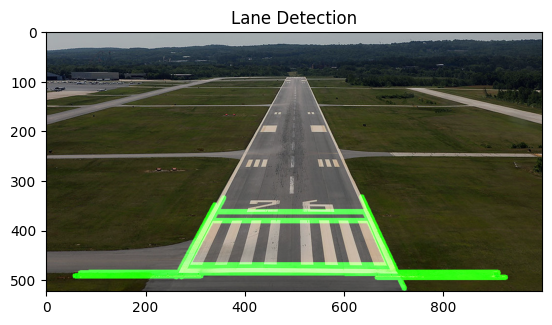

In [ ]:
plt.imshow(cv2.cvtColor(processed_image, cv2.COLOR_BGR2RGB))
plt.title("Lane Detection")
plt.show()